In [1]:
%load_ext autoreload
%autoreload 2

# Import

In [ ]:
import pandas as pd
import numpy as np
import plotly.express as px
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from pathlib import Path
from typing import Union
from glob import glob

import sys
PHASE1_SRC = Path("../Phase1/src/")
if str(PHASE1_SRC) not in sys.path:
    sys.path.insert(0, str(PHASE1_SRC))

from space import Space, GFLOWNET_ENV
from reward import reward_peak, reward_latent
from machinelearning import train_single_model, predict_with_model, preprocess, build_models
from VEM import oracle_fn
from plotting import *

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from umap import UMAP
from sklearn.decomposition import PCA


# Loading

In [3]:
grid = pd.read_csv("grid_results/grid_summary.csv")#.sort_values("run")

In [4]:
grid.head()

,run,status,elapsed_sec,best_reward,mean_reward,sampling_strategy,acquisition,n_candidates_per_iter,n_init,n_iterations,gfn_n_train_steps,n_gfn_samples,seed
0,run_0,ok,13.6,0.175985,0.011412,random,top_k,5,20,10,100,100,42
1,run_1,ok,3.2,0.039155,0.002977,random,top_k,5,20,10,100,100,123
2,run_2,ok,3.4,0.059899,0.003988,random,top_k,5,50,10,100,100,42
3,run_3,ok,3.8,0.057518,0.003037,random,top_k,5,50,10,100,100,123
4,run_4,ok,3.9,0.209684,0.006241,random,top_k,5,100,10,100,100,42


In [5]:
# grid["run"] = grid["run"].str[:7]
# grid["run"] = grid["run"].str.replace("run", "run_")
# grid["run"] = grid["run"].str.replace(r"run_0+(\d+)", r"run_\1", regex=True)

In [6]:
# grid.to_csv("grid_results/grid_summary.csv", index=False)

In [7]:
from glob import glob
paths = sorted(glob("grid_results/*/al_metrics.csv"))
if not paths:
    raise ValueError("No files found at al_results/*/al_metrics.csv")
df = pd.concat([load(p).assign(run=Path(p).parent.name) for p in paths], ignore_index=True)

In [8]:
df.sample()

,iteration,time,n_samples,oracle_evals_total,oracle_evals_this_iter,best_reward_so_far,mean_reward_so_far,proxy_r2,proxy_mae,phase,best_reward_this_iter,mean_reward_this_iter,best_predicted_reward,elapsed_sec,run
238,9,17:16:35,95,95,5,0.275314,0.00743,0.541966,0.085014,gflownet,0.006351,0.001317,0.047784,80.4,run_120


In [9]:
df[df["phase"]=="gflownet"].groupby("run").count().count().iloc[0]

np.int64(144)

In [10]:
best_runs(df)

,run,final_mean_reward,final_best_reward,final_proxy_r2,final_proxy_mae,total_oracle_evals,sampling_strategy
0,run_138,0.013825,0.563934,0.471257,0.071468,120,gflownet
1,run_107,0.004191,0.283794,0.776828,0.059726,350,grid
2,run_65,0.004893,0.372621,0.702720,0.064975,200,lhs
3,run_11,0.007959,0.327987,0.659967,0.061979,200,random


## multi-curves

In [32]:

def plot_run(path: Union[str, Path], title: str = None) -> go.Figure:
    """
    Dashboard for one AL run.

    Subplots
    --------
    Row 1 left  : best reward so far (cumulative max) + this-iter best
    Row 1 right : mean reward so far + this-iter mean
    Row 2 left  : proxy R² over iterations
    Row 2 right : proxy MAE over iterations
    Row 3 left  : oracle evaluations cumulative
    Row 3 right : elapsed time per iteration (sec)
    """
    df = _load(path)
    run = title or Path(path).parent.name

    fig = make_subplots(
        rows=3, cols=2,
        subplot_titles=[
            "Best reward (cumulative)", "Mean reward",
            "Proxy R²", "Proxy MAE",
            "Oracle evaluations (cumulative)", "Time per iteration (s)",
        ],
        vertical_spacing=0.12,
        horizontal_spacing=0.10,
    )

    it = df["iteration"]
    blue, orange = "#4C72B0", "#DD8452"

    # --- Row 1: rewards ---
    fig.add_trace(go.Scatter(
        x=it, y=df["best_reward_so_far"],
        name="Best so far", line=dict(color=blue, width=2),
        mode="lines+markers", marker=dict(size=5),
    ), row=1, col=1)

    if "best_reward_this_iter" in df:
        fig.add_trace(go.Bar(
            x=it, y=df["best_reward_this_iter"],
            name="Best this iter", marker_color=orange, opacity=0.5,
        ), row=1, col=1)

    fig.add_trace(go.Scatter(
        x=it, y=df["mean_reward_so_far"],
        name="Mean so far", line=dict(color=blue, width=2),
        mode="lines+markers", marker=dict(size=5), showlegend=False,
    ), row=1, col=2)

    if "mean_reward_this_iter" in df:
        fig.add_trace(go.Bar(
            x=it, y=df["mean_reward_this_iter"],
            name="Mean this iter", marker_color=orange, opacity=0.5, showlegend=False,
        ), row=1, col=2)

    # --- Row 2: proxy quality ---
    if "proxy_r2" in df:
        r2 = df["proxy_r2"].replace([np.inf, -np.inf], np.nan)
        fig.add_trace(go.Scatter(
            x=it, y=r2,
            name="R²", line=dict(color="#55A868", width=2),
            mode="lines+markers", marker=dict(size=5),
        ), row=2, col=1)
        fig.add_hline(y=0, line=dict(color="grey", dash="dot", width=1), row=2, col=1)
        fig.add_hline(y=1, line=dict(color="grey", dash="dot", width=1), row=2, col=1)

    if "proxy_mae" in df:
        fig.add_trace(go.Scatter(
            x=it, y=df["proxy_mae"],
            name="MAE", line=dict(color="#C44E52", width=2),
            mode="lines+markers", marker=dict(size=5),
        ), row=2, col=2)

    # --- Row 3: oracle evals + time ---
    if "oracle_evals_total" in df:
        fig.add_trace(go.Scatter(
            x=it, y=df["oracle_evals_total"],
            name="Oracle evals", line=dict(color="#8172B3", width=2),
            mode="lines+markers", marker=dict(size=5),
        ), row=3, col=1)

    if "elapsed_sec" in df:
        fig.add_trace(go.Bar(
            x=it, y=df["elapsed_sec"],
            name="Elapsed (s)", marker_color="#937860", opacity=0.7,
        ), row=3, col=2)

    fig.update_layout(
        title=dict(text=f"AL run — <b>{run}</b>", font_size=16),
        height=800,
        legend=dict(bgcolor="rgba(0,0,0,0)", x=1.02, y=1),
        plot_bgcolor="white",
        paper_bgcolor="white",
        hovermode="x unified",
    )
    for row in range(1, 4):
        for col in range(1, 3):
            fig.update_xaxes(title_text="AL iteration", gridcolor="#eeeeee", row=row, col=col)
    fig.update_yaxes(gridcolor="#eeeeee")

    return fig




In [33]:
plot_run("grid_results/run_138/al_metrics.csv")

NameError: name '_load' is not defined

In [ ]:

def compare_runs(
    names: list[str] = None,
) -> go.Figure:
    """
    Compare multiple AL runs side by side.

    Paths can be:
        - explicit list of CSV paths
        - a glob pattern string, e.g. "al_results/*/al_metrics.csv"

    Names default to the parent directory name of each CSV.

    Subplots
    --------
    Row 1 left  : best reward so far per run
    Row 1 right : mean reward so far per run
    Row 2 left  : proxy R² per run
    Row 2 right : oracle evals (efficiency — reward vs evals used)
    """
    from glob import glob
    paths = sorted(glob("grid_results/*/al_metrics.csv"))
    if not paths:
        raise ValueError("No files found at al_results/*/al_metrics.csv")
    if names is None:
        names = [Path(p).parent.name for p in paths]

    colors = _color_seq(len(paths))

    fig = make_subplots(
        rows=2, cols=2,
        subplot_titles=[
            "Best reward so far", "Mean reward so far",
            "Proxy R² over iterations", "Reward vs oracle evaluations",
        ],
        vertical_spacing=0.15,
        horizontal_spacing=0.10,
    )

    for (path, name, color) in zip(paths, names, colors):
        try:
            df = _load(path)
        except Exception as e:
            print(f"Skipping {path}: {e}")
            continue

        it = df["iteration"]
        style = dict(color=color, width=2)

        # best reward
        fig.add_trace(go.Scatter(
            x=it, y=df["best_reward_so_far"],
            name=name, line=style,
            mode="lines+markers", marker=dict(size=4),
            legendgroup=name,
        ), row=1, col=1)

        # mean reward
        fig.add_trace(go.Scatter(
            x=it, y=df["mean_reward_so_far"],
            name=name, line=style,
            mode="lines+markers", marker=dict(size=4),
            legendgroup=name, showlegend=False,
        ), row=1, col=2)

        # proxy R²
        if "proxy_r2" in df:
            r2 = df["proxy_r2"].replace([np.inf, -np.inf], np.nan)
            fig.add_trace(go.Scatter(
                x=it, y=r2,
                name=name, line=style,
                mode="lines+markers", marker=dict(size=4),
                legendgroup=name, showlegend=False,
            ), row=2, col=1)

        # reward vs oracle evals (sample efficiency)
        if "oracle_evals_total" in df:
            fig.add_trace(go.Scatter(
                x=df["oracle_evals_total"], y=df["best_reward_so_far"],
                name=name, line=style,
                mode="lines+markers", marker=dict(size=4),
                legendgroup=name, showlegend=False,
            ), row=2, col=2)

    fig.add_hline(y=0, line=dict(color="grey", dash="dot", width=1), row=2, col=1)

    fig.update_layout(
        title=dict(text=f"AL run comparison ({len(paths)} runs)", font_size=16),
        height=700,
        legend=dict(bgcolor="rgba(0,0,0,0)", x=1.02, y=1),
        plot_bgcolor="white",
        paper_bgcolor="white",
        hovermode="x unified",
    )
    fig.update_xaxes(title_text="AL iteration", gridcolor="#eeeeee", row=1, col=1)
    fig.update_xaxes(title_text="AL iteration", gridcolor="#eeeeee", row=1, col=2)
    fig.update_xaxes(title_text="AL iteration", gridcolor="#eeeeee", row=2, col=1)
    fig.update_xaxes(title_text="Oracle evaluations used", gridcolor="#eeeeee", row=2, col=2)
    fig.update_yaxes(gridcolor="#eeeeee")

    return fig

In [ ]:
compare_runs()

In [ ]:
def plot_grid_summary(grid: pd.DataFrame, save_dir: str = None):
    """Produce a compact set of aggregate plots from a grid search summary.

    Parameters
    ----------
    grid : pd.DataFrame
        Must contain columns:
        run, status, best_reward, mean_reward,
        sampling_strategy, acquisition, n_candidates_per_iter, n_init, seed
    save_dir : str or Path, optional
        If provided, figures are saved as PDFs in this directory.

    Returns
    -------
    dict of matplotlib Figure
    """
    import matplotlib.pyplot as plt

    # Keep only successful runs
    ok = grid[grid["status"] == "ok"].copy()
    if len(ok) == 0:
        print("[plot_grid_summary] No successful runs to plot.")
        return {}

    figs = {}

    # ── helper for bar plots with error bars ──
    def _bar(ax, df, x_label, y_label, title, hue=None, rot=0):
        if hue is None:
            grouped = df.groupby(x_label)["best_reward"]
            means = grouped.mean()
            stds = grouped.std().fillna(0)
            ax.bar(means.index, means.values, yerr=stds.values,
                   capsize=4, color="#4C72B0", edgecolor="white")
        else:
            # Grouped bar: one group per x_label, one bar per hue value
            pivot = df.pivot_table(index=x_label, columns=hue,
                                   values="best_reward", aggfunc="mean")
            err = df.pivot_table(index=x_label, columns=hue,
                                 values="best_reward", aggfunc="std").fillna(0)
            x_pos = range(len(pivot))
            n_hues = len(pivot.columns)
            width = 0.7 / n_hues
            colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52", "#8172B3"]
            for i, col in enumerate(pivot.columns):
                offset = (i - (n_hues - 1) / 2) * width
                ax.bar([p + offset for p in x_pos], pivot[col].values,
                       yerr=err[col].values if not err.empty else None,
                       width=width, label=str(col), capsize=3,
                       color=colors[i % len(colors)], edgecolor="white")
            ax.legend(title=hue)
        ax.set_xticks(range(len(ok[x_label].unique())))
        ax.set_xticklabels(sorted(ok[x_label].unique()), rotation=rot)
        ax.set_ylabel(y_label)
        ax.set_title(title)
        ax.grid(axis="y", alpha=0.3)

    # ── 1. Best reward by sampling strategy (averaged over everything) ──
    fig1, ax1 = plt.subplots(figsize=(6, 4))
    _bar(ax1, ok, "sampling_strategy",
         "Best reward (mean ± std)", "Best reward by strategy")
    figs["grid_best_by_strategy"] = fig1

    # ── 2. Best reward by strategy × acquisition ──
    fig2, ax2 = plt.subplots(figsize=(7, 4))
    _bar(ax2, ok, "sampling_strategy", "Best reward",
         "Best reward by strategy and acquisition", hue="acquisition", rot=15)
    figs["grid_best_strategy_acq"] = fig2

    # ── 3. Effect of initial dataset size ──
    fig3, ax3 = plt.subplots(figsize=(7, 4))
    _bar(ax3, ok, "n_init", "Best reward",
         "Effect of initial sample budget", hue="sampling_strategy")
    figs["grid_best_vs_n_init"] = fig3

    # ── 4. Effect of candidates per iteration ──
    fig4, ax4 = plt.subplots(figsize=(7, 4))
    _bar(ax4, ok, "n_candidates_per_iter", "Best reward",
         "Effect of candidates per iteration", hue="sampling_strategy")
    figs["grid_best_vs_n_candidates"] = fig4

    # ── 5. Top-10 runs ──
    top10 = ok.nlargest(10, "best_reward")
    fig5, ax5 = plt.subplots(figsize=(10, 5))
    colors = {"gflownet": "#4C72B0", "random": "#DD8452",
              "lhs": "#55A868", "grid": "#C44E52"}
    bar_colors = [colors.get(s, "#636363") for s in top10["sampling_strategy"]]
    bars = ax5.barh(range(len(top10)), top10["best_reward"].values,
                    color=bar_colors, edgecolor="white")
    ax5.set_yticks(range(len(top10)))
    ax5.set_yticklabels(top10["run"].values)
    ax5.invert_yaxis()
    ax5.set_xlabel("Best reward")
    ax5.set_title("Top-10 configurations")
    from matplotlib.patches import Patch
    legend_elements = [Patch(facecolor=c, label=s)
                       for s, c in colors.items()]
    ax5.legend(handles=legend_elements, title="Strategy")
    ax5.grid(axis="x", alpha=0.3)
    figs["grid_top10"] = fig5

    if save_dir:
        save_dir = Path(save_dir)
        save_dir.mkdir(parents=True, exist_ok=True)
        for name, fig in figs.items():
            fig.savefig(save_dir / f"{name}.pdf", bbox_inches="tight")
        print(f"[plot_grid_summary] Saved {len(figs)} figures → {save_dir}")

    return figs

{'grid_best_by_strategy': <Figure size 600x400 with 1 Axes>,
 'grid_best_strategy_acq': <Figure size 700x400 with 1 Axes>,
 'grid_best_vs_n_init': <Figure size 700x400 with 1 Axes>,
 'grid_best_vs_n_candidates': <Figure size 700x400 with 1 Axes>,
 'grid_top10': <Figure size 1000x500 with 1 Axes>}

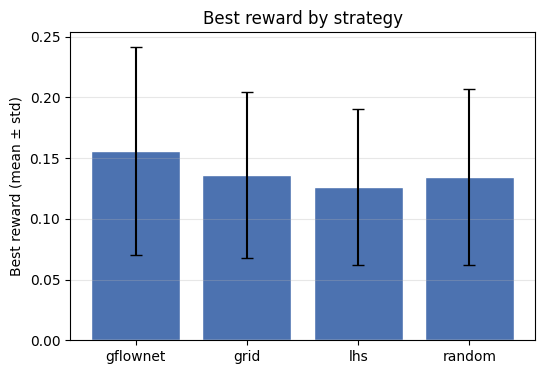

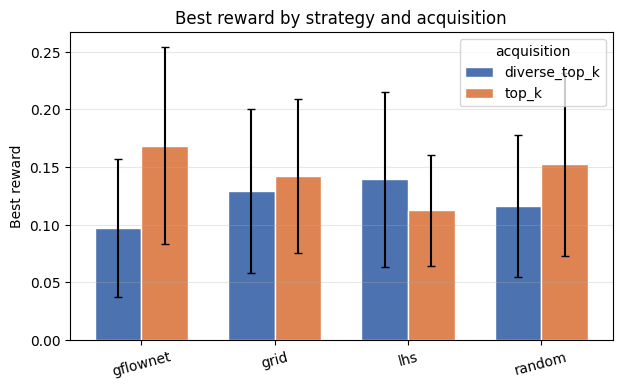

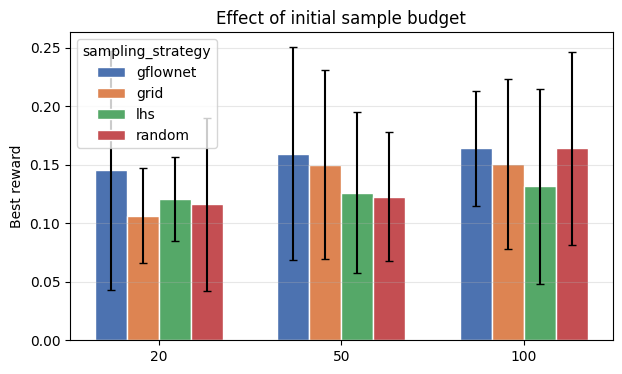

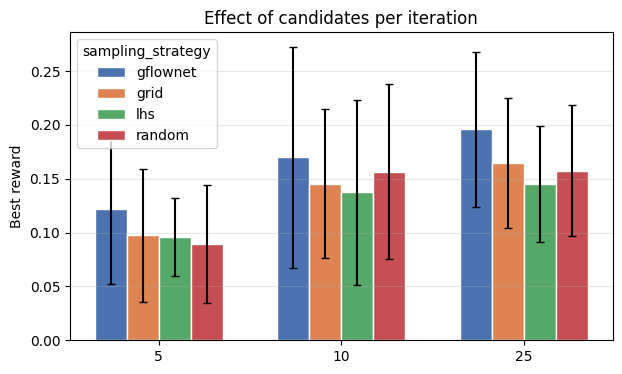

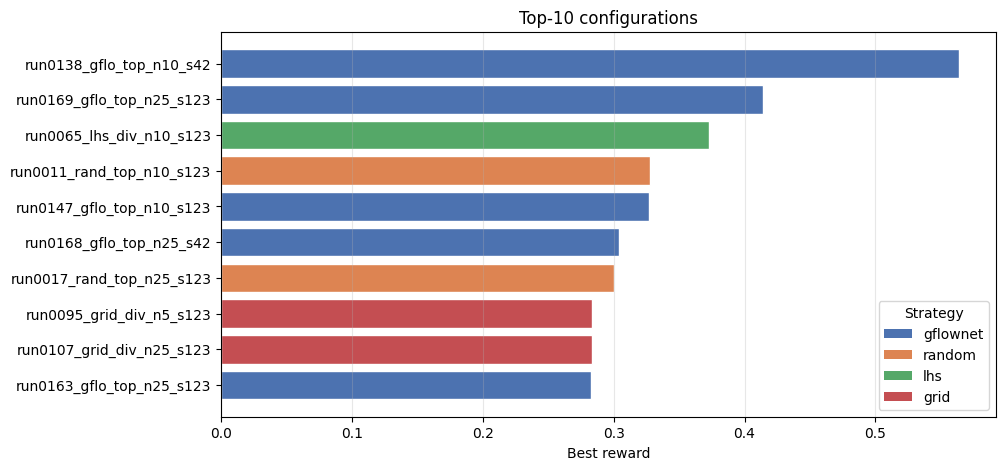

In [ ]:
plot_grid_summary(grid)

## reset

In [11]:
all_metrics = attach_grid_metadata(df, grid)

In [12]:
metrics, grid = load_metrics("grid_results")

In [13]:
select_best_runs(metrics, metric="best_reward")

,iteration,time,n_samples,oracle_evals_total,oracle_evals_this_iter,best_reward_so_far,mean_reward_so_far,proxy_r2,proxy_mae,phase,...,best_reward,mean_reward,sampling_strategy,acquisition,n_candidates_per_iter,n_init,n_iterations,gfn_n_train_steps,n_gfn_samples,seed
420,1,21:05:00,30,30,10,0.236264,0.008129,-0.968504,0.100598,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
421,2,21:06:22,40,40,10,0.236264,0.009016,-0.296350,0.097016,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
422,3,21:07:43,50,50,10,0.236264,0.010488,0.260422,0.072997,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
423,4,21:09:04,60,60,10,0.236264,0.013007,0.490447,0.072672,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
424,5,21:10:26,70,70,10,0.236264,0.013179,0.177810,0.070584,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
425,6,21:11:47,80,80,10,0.236264,0.011746,0.338502,0.069594,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
426,7,21:13:09,90,90,10,0.236264,0.011005,0.402904,0.066162,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
427,8,21:14:31,100,100,10,0.236264,0.010608,0.398572,0.073742,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
428,9,21:15:53,110,110,10,0.563934,0.014895,0.541887,0.065770,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42
429,10,21:17:15,120,120,10,0.563934,0.013825,0.471257,0.071468,gflownet,...,0.563934,0.013825,gflownet,top_k,10,20,10,500,500,42


In [14]:
plot_reward_curves(metrics, metric="mean_reward_this_iter", title="Mean reward per iteration")

In [15]:
aggregate_seeds(metrics, "mean_reward_this_iter", groupby=("sampling_strategy",)).groupby(["sampling_strategy", "iteration"]).agg(
    mean=("mean", "mean"),
    std=("std", "mean"),
    sem=("sem", "mean"),
    ci95=("ci95", "mean"),
)

mean       std       sem      ci95
sampling_strategy iteration                                        
gflownet          1          0.009221  0.007418  0.005246  0.010281
                  2          0.006273  0.003995  0.002825  0.005537
                  3          0.006635  0.004487  0.003172  0.006218
                  4          0.007999  0.004918  0.003478  0.006816
                  5          0.008400  0.005044  0.003566  0.006990
                  6          0.007661  0.006145  0.004345  0.008517
                  7          0.008496  0.006357  0.004495  0.008811
                  8          0.006407  0.004163  0.002944  0.005770
                  9          0.005977  0.003784  0.002676  0.005245
                  10         0.008784  0.005856  0.004141  0.008116
grid              1          0.003045  0.002858  0.002021  0.003961
                  2          0.002901  0.001760  0.001245  0.002440
                  3          0.005369  0.004207  0.002975  0.005830
                  4          0.006076  0.003910  0.002764  0.005418
                  5          0.006056  0.004708  0.003329  0.006525
                  6          0.008027  0.006458  0.004567  0.008951
                  7          0.006994  0.004033  0.002851  0.005589
                  8          0.005323  0.003361  0.002377  0.004658
                  9          0.007693  0.006283  0.004443  0.008708
                  10         0.009527  0.006799  0.004807  0.009423
lhs               1          0.004405  0.003359  0.002375  0.004655
                  2          0.004361  0.003146  0.002224  0.004360
                  3          0.005454  0.003087  0.002183  0.004278
                  4          0.007765  0.005674  0.004012  0.007863
                  5          0.007182  0.003397  0.002402  0.004708
                  6          0.004327  0.002550  0.001803  0.003534
                  7          0.006069  0.004289  0.003033  0.005945
                  8          0.006154  0.004325  0.003058  0.005994
                  9          0.003407  0.001991  0.001408  0.002759
                  10         0.008230  0.005461  0.003861  0.007568
random            1          0.006350  0.003708  0.002622  0.005139
                  2          0.006017  0.004348  0.003075  0.006027
                  3          0.005952  0.005617  0.003972  0.007785
                  4          0.008688  0.005327  0.003767  0.007383
                  5          0.006282  0.004210  0.002977  0.005835
                  6          0.007924  0.006040  0.004271  0.008371
                  7          0.007429  0.006687  0.004728  0.009268
                  8          0.005424  0.004095  0.002895  0.005675
                  9          0.003823  0.002940  0.002079  0.004074
                  10         0.008579  0.005953  0.004209  0.008250

In [16]:
plot_seed_variance(metrics, metric="mean_reward_this_iter")

In [17]:
plot_oracle_efficiency(metrics, metric="mean_reward_this_iter")

In [18]:
plot_proxy_curves(metrics)

In [19]:
plot_final_boxplot(metrics, metric="best_reward")

In [21]:
plot_reward_heatmap(metrics, metric="best_reward")

In [22]:
plot_budget_tradeoff(metrics, metric="best_reward")

In [28]:
embedding, preprocessor, reducer = compute_global_embedding(
    method="UMAP"
)

c:\Users\valen\AppData\Local\Programs\Python\Python310\lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


In [47]:
fig, _ = visualize_run("run_222", preprocessor=preprocessor, reducer=reducer)

0.13039266042310735


In [50]:
import numpy as np
for _ in range(5):
    s = reconstruct_sampling_history("run_222")
    print(s['reward'].max() if 'reward' in s else "no reward col yet")
    t = add_reward(s)
    print(t['reward'].max() if 'reward' in t else "no reward col yet")

no reward col yet
0.24744198968625178
no reward col yet
0.1585672545518775
no reward col yet
0.1753066291158804
no reward col yet
0.1572187370595749
no reward col yet
0.21336988522117212


In [43]:
fig